In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr=learning_rate
        self.epochs=epochs
    
    def fit(self, X, y):
        self.weights=np.zeros(X.shape[1])
        self.bias=0
        
        for _ in range(self.epochs):
            for i in range(len(X)):
                linear_output=np.dot(X[i], self.weights)+self.bias
                y_pred=self.activation(linear_output)

                error=y[i]-y_pred
                self.weights+=self.lr*error*X[i]
                self.bias+=self.lr*error
    
    def predict(self, X):
        linear_output=np.dot(X, self.weights)+self.bias
        return self.activation(linear_output)
    
    def activation(self, x):
        return np.where(x>=0, 1, 0)

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

In [4]:
y_and=np.array([0, 0, 0, 1])

perceptron_and=Perceptron(learning_rate=0.1, epochs=10)
perceptron_and.fit(X, y_and)

print("AND Predictions:")
print(perceptron_and.predict(X))
print("Weights:", perceptron_and.weights, "Bias:", perceptron_and.bias)

AND Predictions:
[0 0 0 1]
Weights: [0.2 0.1] Bias: -0.20000000000000004


In [5]:
y_or=np.array([0, 1, 1, 1])

perceptron_or=Perceptron(learning_rate=0.1, epochs=10)
perceptron_or.fit(X, y_or)

print("OR Predictions:")
print(perceptron_or.predict(X))
print("Weights:", perceptron_or.weights, "Bias:", perceptron_or.bias)

OR Predictions:
[0 1 1 1]
Weights: [0.1 0.1] Bias: -0.1


In [6]:
y_xor=np.array([0, 1, 1, 0])

perceptron_xor=Perceptron(learning_rate=0.1, epochs=10)
perceptron_xor.fit(X, y_xor)

print("XOR Predictions:")
print(perceptron_xor.predict(X))
print("Weights:", perceptron_xor.weights, "Bias:", perceptron_xor.bias)

XOR Predictions:
[1 1 0 0]
Weights: [-0.1  0. ] Bias: 0.0


In [7]:
def plot_decision_boundary(X, y, model, title):
    plt.figure()

    for i in range(len(X)):
        if y[i]==0:
            plt.scatter(X[i][0], X[i][1], color='red')
        else:
            plt.scatter(X[i][0], X[i][1], color='blue')

    x_vals=np.linspace(-0.5, 1.5, 100)
    
    if model.weights[1]!=0:
        y_vals=-(model.weights[0]*x_vals+model.bias)/model.weights[1]
        plt.plot(x_vals, y_vals)
    
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    plt.show()

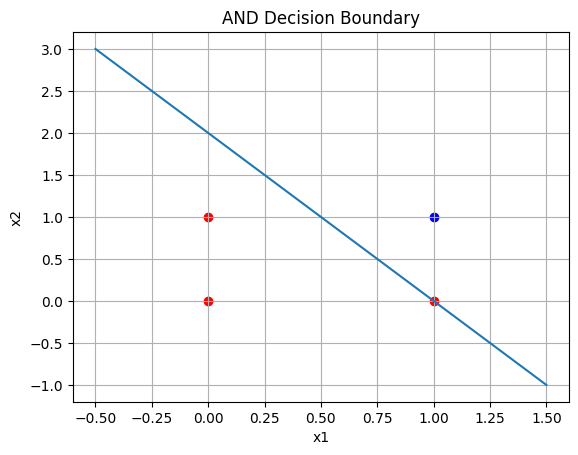

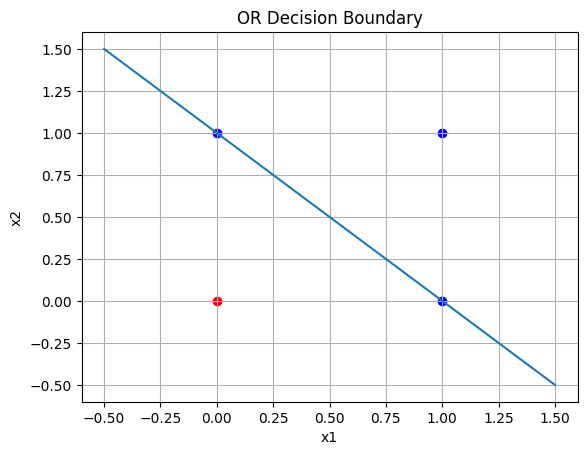

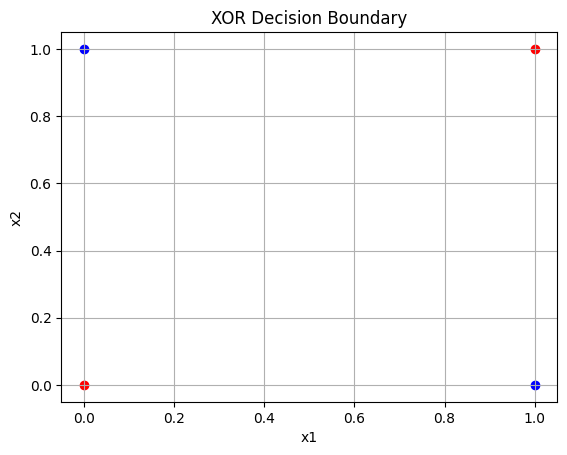

In [8]:
plot_decision_boundary(X, y_and, perceptron_and, "AND Decision Boundary")
plot_decision_boundary(X, y_or, perceptron_or, "OR Decision Boundary")
plot_decision_boundary(X, y_xor, perceptron_xor, "XOR Decision Boundary")